# MapleFreight Logistics — Delivery Delay Prediction & Slack Alerts

**Contents**
1. Context, problem statement and objectives
2. Setup
3. Data understanding
4. Data preprocessing (cleaning)
5. Exploratory data analysis
6. Feature engineering
7. Data preparation (split + pipeline)
8. Modelling (baseline vs. candidates)
9. Model evaluation and threshold selection
10. Model explainability
11. Slack alert integration
12. Recommendations

## 1. Context, problem statement and objectives
**Context.** MapleFreight moves ~8,000 shipments a week across Ontario, Quebec and the Prairies. On-time performance fell from 94% to 88% this year, and late deliveries are only discovered when the customer calls — after service credits and re-delivery costs are already incurred.

**Problem.** Predict, at dispatch time, whether an in-transit shipment will be delivered late, and alert dispatch in Slack early enough to re-route or warn the customer.

**Objectives**
1. Identify the main drivers of late delivery.
2. Build a classifier for `delivered_late`, compared against a baseline.
3. Send automatic Slack alerts for high-risk shipments.
4. Give actionable recommendations to improve on-time performance.

**Key modelling constraint.** `actual_transit_hours` is recorded *on delivery* and is not available at prediction time. Using it would be target leakage, so it is excluded from the model features.

## 2. Setup

In [60]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import requests
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, classification_report)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
DATA_PATH = "maplefreight_delivery_delay_dataset.csv"


## 3. Data understanding

In [61]:
raw = pd.read_csv(DATA_PATH)
print("Shape:", raw.shape)
raw.head()

Shape: (6035, 23)


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,...,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,...,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,...,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,...,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,...,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


In [62]:
print(raw.dtypes, "\n")
print("Missing values per column:")
print(raw.isna().sum()[raw.isna().sum() > 0])
print("\nFully duplicated rows:", raw.duplicated().sum())
print("Repeated shipment_ids :", raw.shipment_id.duplicated().sum())
print("\nservice_level spellings:", raw.service_level.value_counts().to_dict())
print("\nTarget balance:\n", raw.delivered_late.value_counts(normalize=True).round(3))

shipment_id                      str
origin_city                      str
destination_city                 str
carrier                          str
service_level                    str
goods_type                       str
customer_priority_tier           str
shipment_month                 int64
distance_km                  float64
weight_kg                    float64
num_stops                      int64
is_cross_border                int64
scheduled_transit_hours      float64
pickup_delay_minutes         float64
driver_experience_years      float64
vehicle_age_years            float64
weather_condition                str
traffic_index                float64
route_congestion_score       float64
prior_late_deliveries_30d      int64
fuel_cost_cad                float64
actual_transit_hours         float64
delivered_late                 int64
dtype: object 

Missing values per column:
driver_experience_years    210
weather_condition          150
traffic_index              121
fuel_cost_cad

In [63]:
raw[["weight_kg","distance_km","scheduled_transit_hours","pickup_delay_minutes",
     "driver_experience_years","vehicle_age_years","traffic_index","fuel_cost_cad"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
weight_kg,6035.0,6928.25,83755.15,30.0,496.00,827.10,1286.30,2999300.00
distance_km,6035.0,632.19,319.25,80.5,398.60,571.10,804.85,2556.70
scheduled_transit_hours,6035.0,10.50,4.76,1.0,7.06,9.85,13.18,37.40
pickup_delay_minutes,6035.0,20.37,30.62,-20.0,-6.00,18.00,41.00,146.00
driver_experience_years,5825.0,6.50,4.66,0.2,3.20,5.40,8.60,35.00
vehicle_age_years,6035.0,5.49,3.43,0.1,3.00,4.80,7.20,20.00
traffic_index,5914.0,55.15,17.59,5.0,43.30,55.00,67.20,100.00
fuel_cost_cad,5795.0,180.70,58.76,30.0,140.60,181.18,220.95,392.01


In [64]:
print("Rows with weight_kg > 50,000 :", (raw.weight_kg > 50_000).sum())
print("Largest 'normal' weight       :", raw.loc[raw.weight_kg <= 50_000, "weight_kg"].max())
print("Smallest flagged weight       :", raw.loc[raw.weight_kg > 50_000, "weight_kg"].min())
print("Rows where origin == destination:", (raw.origin_city == raw.destination_city).sum())

Rows with weight_kg > 50,000 : 40
Largest 'normal' weight       : 5044.0
Smallest flagged weight       : 170900.0
Rows where origin == destination: 466


**Findings.**
- 6,035 rows × 23 columns. The target is 20.6% late, so a model that always says "on time" gets ~79% accuracy and catches nothing.
- Data-quality problems found: **32 exact duplicate rows** and **3 more `shipment_id`s that repeat with different values**; **`service_level` in mixed case** (120 rows, e.g. `standard`); **40 weights in grams, not kg** (smallest 170,900 vs. a real maximum around 5,000; mean weight was 6,928 kg before fixing); missing values in `driver_experience_years` (210), `fuel_cost_cad` (240), `weather_condition` (150) and `traffic_index` (121).
- 466 shipments have the same origin and destination city. I kept them: they may be local deliveries, they have normal distances, and I have no evidence they are errors. I flag them with a `same_city` feature rather than deleting them.
- `actual_transit_hours` is only known after delivery, so it is **excluded as leakage**.

## 4. Data preprocessing

In [65]:
df = raw.copy()

# 1) Exact duplicate rows, then conflicting records that reuse a shipment_id (keep the first occurrence)
n0 = len(df)
df = df.drop_duplicates()
n1 = len(df)
df = df.drop_duplicates(subset="shipment_id", keep="first")
print(f"Removed {n0-n1} exact duplicates and {n1-len(df)} conflicting shipment_id repeats -> {len(df)} rows")

# 2) Inconsistent spellings
df["service_level"] = df["service_level"].str.strip().str.title()

# 3) Unit error: weights > 50,000 are recorded in grams (x1000) -> convert to kg
unit_mask = df.weight_kg > 50_000
df.loc[unit_mask, "weight_kg"] = df.loc[unit_mask, "weight_kg"] / 1000
print(f"Converted {unit_mask.sum()} weights from grams to kg; new max weight = {df.weight_kg.max():,.0f} kg")

# 4) Missing weather is a legitimate 'forecast not available' state -> own category
df["weather_condition"] = df["weather_condition"].fillna("Unknown")

# 5) Remaining numeric gaps are imputed inside the model pipeline (fit on train only, avoids leakage)
print("\nMissing after cleaning:\n", df.isna().sum()[df.isna().sum() > 0])
df = df.reset_index(drop=True)

Removed 32 exact duplicates and 3 conflicting shipment_id repeats -> 6000 rows
Converted 40 weights from grams to kg; new max weight = 5,044 kg

Missing after cleaning:
 driver_experience_years    210
traffic_index              120
fuel_cost_cad              240
dtype: int64


**Findings.** After cleaning there are **6,000 shipments** (35 rows removed). Weights are now in a sensible range (30–5,044 kg), `service_level` has three clean values, and missing weather is its own `Unknown` category (those rows are late at a normal ~22%, so "unknown" is not itself a risk signal). The remaining numeric gaps (driver experience, traffic, fuel cost) are median-imputed with a missing-indicator **inside the pipeline**, so no information from validation/test leaks into the fit. Rows were not dropped for missingness (3–4% each).

## 5. Exploratory data analysis

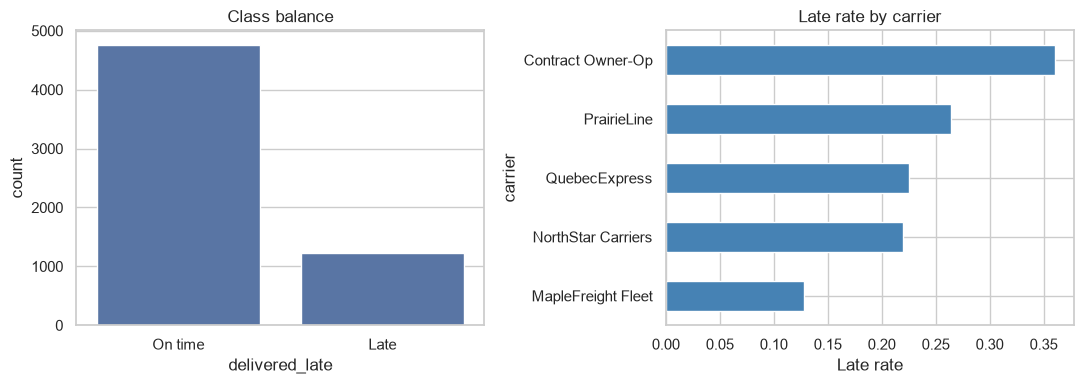

Overall late rate: 0.206


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="delivered_late", data=df, ax=axes[0])
axes[0].set_title("Class balance"); axes[0].set_xticklabels(["On time", "Late"])
df.groupby("carrier").delivered_late.mean().sort_values().plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Late rate by carrier"); axes[1].set_xlabel("Late rate")
plt.tight_layout(); plt.show()
print("Overall late rate:", round(df.delivered_late.mean(), 3))

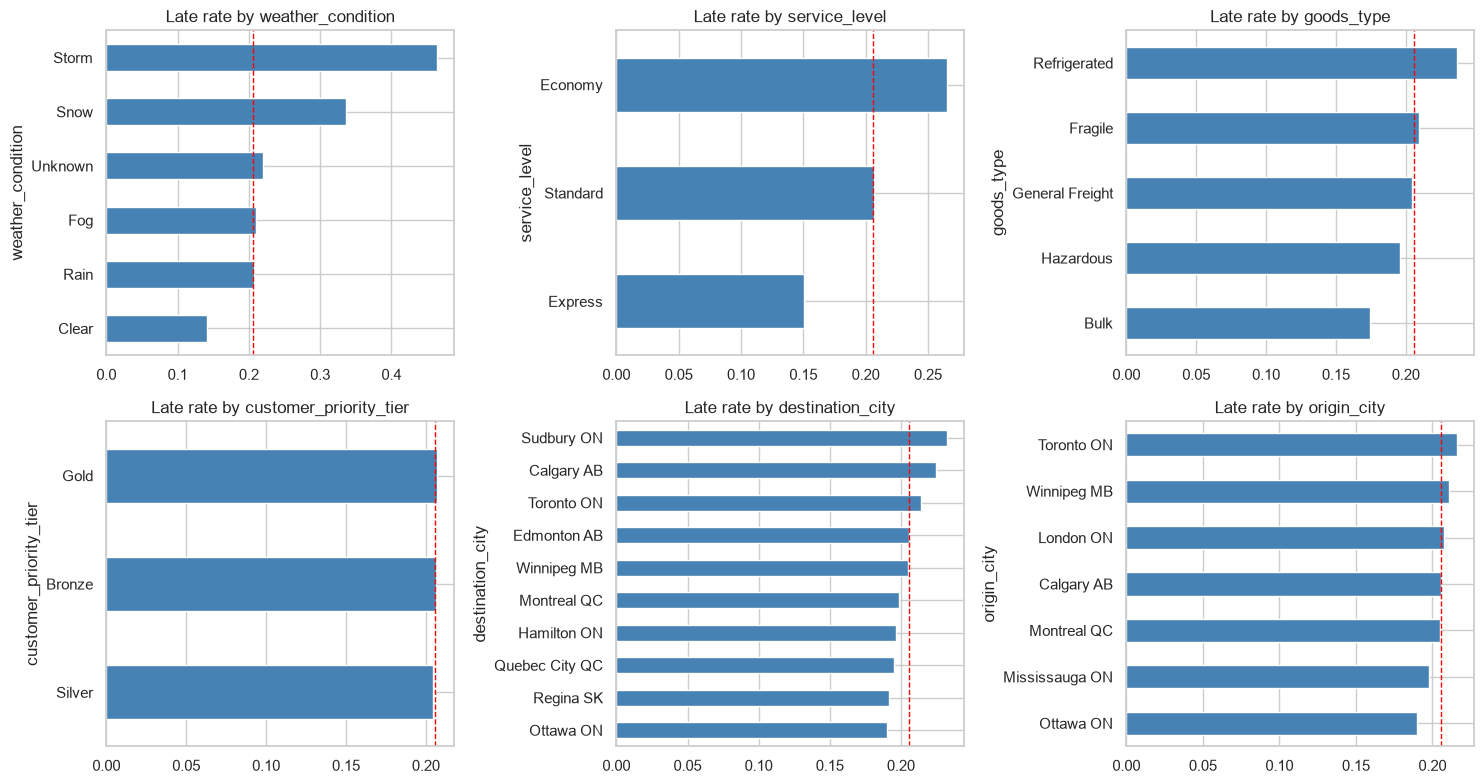

In [67]:
cats = ["weather_condition", "service_level", "goods_type", "customer_priority_tier", "destination_city", "origin_city"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), cats):
    rate = df.groupby(c).delivered_late.mean().sort_values()
    rate.plot.barh(ax=ax, color="steelblue"); ax.axvline(df.delivered_late.mean(), color="red", ls="--", lw=1)
    ax.set_title(f"Late rate by {c}"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

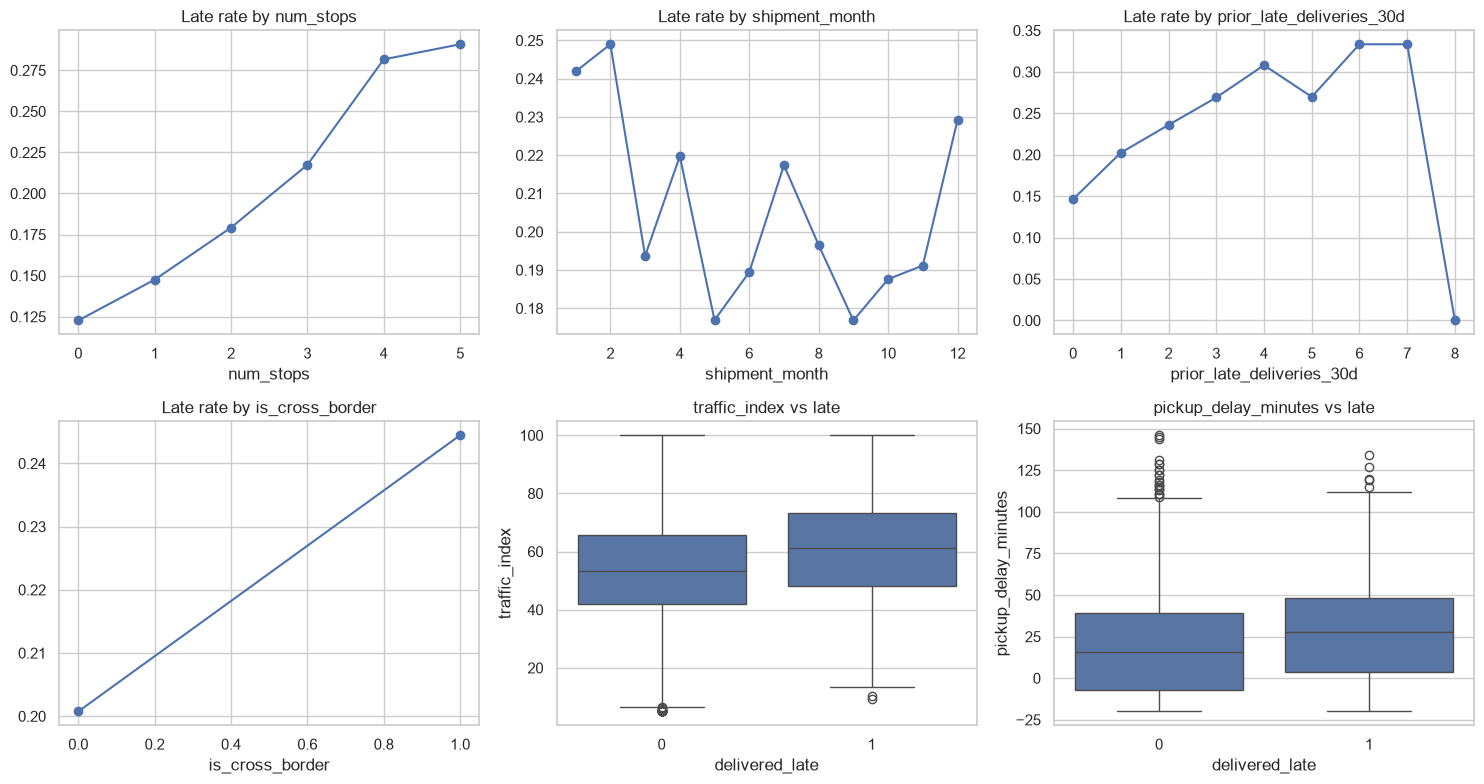

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), ["num_stops", "shipment_month", "prior_late_deliveries_30d", "is_cross_border"]):
    df.groupby(c).delivered_late.mean().plot(marker="o", ax=ax); ax.set_title(f"Late rate by {c}")
for ax, c in zip(axes.ravel()[4:], ["traffic_index", "pickup_delay_minutes"]):
    sns.boxplot(x="delivered_late", y=c, data=df, ax=ax); ax.set_title(f"{c} vs late")
plt.tight_layout(); plt.show()

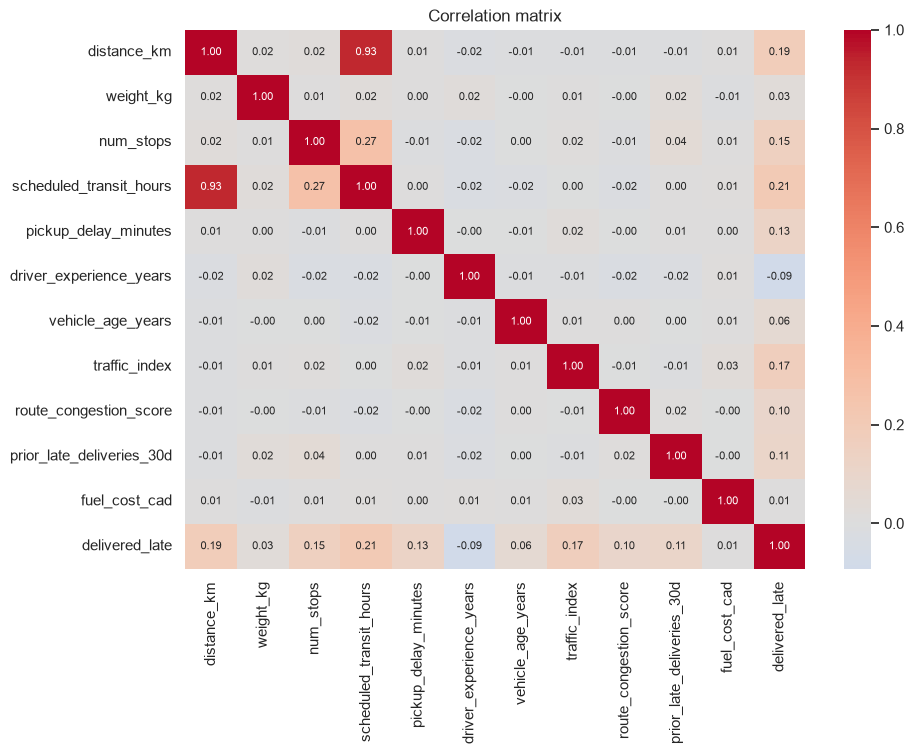

In [69]:
num_cols = ["distance_km","weight_kg","num_stops","scheduled_transit_hours","pickup_delay_minutes","driver_experience_years",
            "vehicle_age_years","traffic_index","route_congestion_score","prior_late_deliveries_30d","fuel_cost_cad","delivered_late"]
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 8})
plt.title("Correlation matrix"); plt.show()

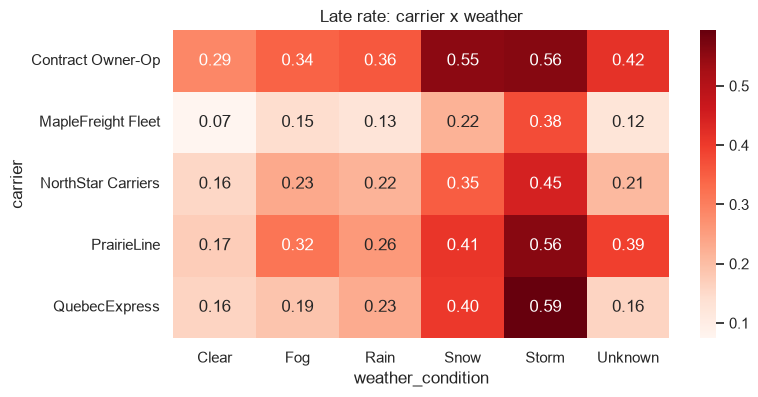

In [70]:
# Carrier x weather interaction
pivot = df.pivot_table(index="carrier", columns="weather_condition", values="delivered_late", aggfunc="mean")
plt.figure(figsize=(8, 4)); sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds"); plt.title("Late rate: carrier x weather"); plt.show()

**Findings (late rate overall = 20.6%).**
- **Weather is the strongest single driver:** clear 14.1%, rain/fog ~21%, **snow 33.6%, storm 46.5%**.
- **Carrier matters a lot:** own fleet 12.8% vs **contract owner-operators 36.0%** (PrairieLine 26.4%, QuebecExpress 22.5%, NorthStar 22.0%). The gap widens in bad weather — owner-operators are late 55%+ of the time in snow/storm, and even the own fleet reaches 38% in a storm.
- **More stops = more delays:** 12% with 0 stops rising steadily to 29% with 5.
- **Traffic and pickup delay:** the top traffic quartile is late 29.8% vs 13.1% for the lowest; shipments picked up >30 min late are late ~26% vs 14.6% for on-time/early pickups.
- **Service level:** Economy 26.6%, Standard 20.7%, Express 15.1%.
- **Smaller effects:** more prior carrier lates in 30 days (0 → 14.6%, 4 → 30.8%), less-experienced drivers (<3.2 yrs: 24.6% vs >8.7 yrs: 15.5%), older vehicles, cross-border (24.4% vs 20.1%) and winter months (Jan/Feb ≈ 24–25%).
- **No signal:** customer priority tier (Gold/Silver/Bronze all ≈ 20.6%), origin and destination city, and goods type are nearly flat. Individually, no numeric feature correlates with lateness above ~0.21, so this is a problem of many moderate effects — expect a useful but not near-perfect model.

## 6. Feature engineering

Features are built only from information available **at dispatch**. Ideas, each tied to a plausible operational mechanism:
- `planned_speed_kmh` — distance / scheduled hours: a tight promise on a long route is hard to keep.
- `pickup_delay_share` — late pickup relative to the transit budget: the same 60 min hurts a 2-hour trip far more than a 20-hour one.
- `hours_per_stop` — time budget per intermediate stop.
- `severe_weather`, `winter_month`, `owner_operator`, `same_city`, `prairie_dest`, `log_weight`.

In [71]:
def add_features(d):
    d = d.copy()
    d["planned_speed_kmh"] = d.distance_km / d.scheduled_transit_hours
    d["pickup_delay_share"] = (d.pickup_delay_minutes.clip(lower=0) / 60) / d.scheduled_transit_hours
    d["hours_per_stop"] = d.scheduled_transit_hours / (d.num_stops + 1)
    d["severe_weather"] = d.weather_condition.isin(["Snow", "Storm"]).astype(int)
    d["winter_month"] = d.shipment_month.isin([12, 1, 2, 3]).astype(int)
    d["owner_operator"] = (d.carrier == "Contract Owner-Op").astype(int)
    d["same_city"] = (d.origin_city == d.destination_city).astype(int)
    d["prairie_dest"] = d.destination_city.str.contains(" (AB|SK|MB)$", regex=True).astype(int)
    d["log_weight"] = np.log1p(d.weight_kg)
    return d

df_fe = add_features(df)
new = ["planned_speed_kmh","pickup_delay_share","hours_per_stop","severe_weather","winter_month","owner_operator","same_city","prairie_dest","log_weight"]
print(df_fe[new + ["delivered_late"]].corr().delivered_late.drop("delivered_late").round(3).sort_values())

planned_speed_kmh    -0.043
prairie_dest          0.001
same_city             0.002
pickup_delay_share    0.003
hours_per_stop        0.006
log_weight            0.016
winter_month          0.040
owner_operator        0.130
severe_weather        0.195
Name: delivered_late, dtype: float64


**Findings.** Of the engineered features, only `severe_weather` (r = 0.195) and `owner_operator` (r = 0.130) show a visible association, and both are simply regrouped versions of columns that were already there. `planned_speed_kmh`, `pickup_delay_share`, `hours_per_stop`, `same_city`, `prairie_dest` and `log_weight` are close to uncorrelated with the target. I keep them as candidates, but section 8 tests whether they actually help — and they turn out not to.

## 7. Data preparation

In [72]:
TARGET = "delivered_late"
LEAKY = ["actual_transit_hours"]          # recorded on delivery -> not available at prediction time
ID = ["shipment_id"]

X = df_fe.drop(columns=[TARGET] + LEAKY)
y = df_fe[TARGET]

# 60 / 20 / 20 stratified split: train (fit), validation (choose model + threshold), test (final, untouched)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=RANDOM_STATE)
for n, a in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{n:5s}: {len(a):5d} rows, late rate {a.mean():.3f}")

cat_cols = ["origin_city","destination_city","carrier","service_level","goods_type","customer_priority_tier","weather_condition"]
num_cols_m = [c for c in X.columns if c not in cat_cols + ID]
print("\nCategorical:", len(cat_cols), "| Numeric:", len(num_cols_m))

ENGINEERED = ["planned_speed_kmh","pickup_delay_share","hours_per_stop","severe_weather","winter_month","owner_operator","same_city","prairie_dest","log_weight"]
raw_num_cols = [c for c in num_cols_m if c not in ENGINEERED]     # baseline sees only the original (cleaned) columns

def make_preprocessor(scale, nums=None):
    nums = nums or num_cols_m
    num_steps = [("imp", SimpleImputer(strategy="median", add_indicator=True))]
    if scale: num_steps.append(("sc", StandardScaler()))
    return ColumnTransformer([("num", Pipeline(num_steps), nums),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

train:  3600 rows, late rate 0.206
val  :  1200 rows, late rate 0.206
test :  1200 rows, late rate 0.206

Categorical: 7 | Numeric: 22


**Imbalance handling.** About 21% of shipments are late. I use `class_weight="balanced"` (errors on late shipments cost more during training) rather than resampling, and I evaluate with precision, recall, F1 and PR-AUC instead of accuracy. Imputation and scaling live inside the pipeline so they are fit on training data only.

## 8. Modelling

In [73]:
models = {
    "Dummy (always on time)":        Pipeline([("pre", make_preprocessor(False, raw_num_cols)), ("m", DummyClassifier(strategy="most_frequent"))]),
    "Baseline: Logistic Regression": Pipeline([("pre", make_preprocessor(True, raw_num_cols)),     # raw features only
                                               ("m", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "LogReg + engineered features":  Pipeline([("pre", make_preprocessor(True)),
                                               ("m", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Random Forest":                 Pipeline([("pre", make_preprocessor(False)),
                                               ("m", RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight="balanced",
                                                                            n_jobs=-1, random_state=RANDOM_STATE))]),
    "Hist Gradient Boosting":        Pipeline([("pre", make_preprocessor(False)),
                                               ("m", HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, max_depth=4,
                                                                                    l2_regularization=1.0, class_weight="balanced",
                                                                                    random_state=RANDOM_STATE))]),
}
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, pipe in models.items():
    p = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    rows.append({"model": name, "CV ROC-AUC": roc_auc_score(y_train, p), "CV PR-AUC": average_precision_score(y_train, p)})
cv_table = pd.DataFrame(rows).set_index("model").round(3)
cv_table

,CV ROC-AUC,CV PR-AUC
model,,
Dummy (always on time),0.500,0.206
Baseline: Logistic Regression,0.811,0.547
LogReg + engineered features,0.810,0.546
Random Forest,0.786,0.501
Hist Gradient Boosting,0.784,0.516


**Findings (5-fold CV on the training set only).** Every model beats the dummy (PR-AUC 0.206 = the late rate). The logistic-regression **baseline is already very strong (PR-AUC 0.547)**; adding the engineered features changes nothing (0.546), and Random Forest (0.501) and gradient boosting (0.525) are *worse* than the baseline. That suggests the signal is mostly additive and monotonic (weather, traffic, stops...) with little interaction structure for trees to exploit, while the trees overfit the noise in 3,600 rows.

In [74]:
# Light tuning (5-fold CV on train, optimising PR-AUC) of the engineered logistic regression and the boosted trees
from sklearn.model_selection import GridSearchCV
lr_grid = GridSearchCV(models["LogReg + engineered features"], {"m__C": [0.01, 0.03, 0.1, 0.3, 1, 3]},
                       scoring="average_precision", cv=cv, n_jobs=-1).fit(X_train, y_train)
gb_grid = GridSearchCV(models["Hist Gradient Boosting"],
    {"m__learning_rate": [0.03, 0.06], "m__max_depth": [3, 4, None], "m__max_iter": [150, 300], "m__min_samples_leaf": [20, 60]},
    scoring="average_precision", cv=cv, n_jobs=-1).fit(X_train, y_train)
print("Tuned LogReg params:", lr_grid.best_params_, "| CV PR-AUC:", round(lr_grid.best_score_, 3))
print("Tuned HGB params   :", gb_grid.best_params_, "| CV PR-AUC:", round(gb_grid.best_score_, 3))
models["Tuned LogReg + engineered"] = lr_grid.best_estimator_
models["Tuned Hist Gradient Boosting"] = gb_grid.best_estimator_

# Final model = best CV PR-AUC among the candidates (selection uses training data only, never the test set)
cv_scores = {"Tuned LogReg + engineered": lr_grid.best_score_, "Tuned Hist Gradient Boosting": gb_grid.best_score_,
             "Random Forest": cv_table.loc["Random Forest", "CV PR-AUC"]}
best_name = max(cv_scores, key=cv_scores.get)
print("\nSelected final model:", best_name)

Tuned LogReg params: {'m__C': 0.03} | CV PR-AUC: 0.556
Tuned HGB params   : {'m__learning_rate': 0.03, 'm__max_depth': 3, 'm__max_iter': 300, 'm__min_samples_leaf': 20} | CV PR-AUC: 0.531

Selected final model: Tuned LogReg + engineered


## 9. Model evaluation

In [75]:
def metrics_at(y_true, p, thr=0.5):
    pred = (p >= thr).astype(int)
    return dict(accuracy=accuracy_score(y_true, pred), precision=precision_score(y_true, pred, zero_division=0),
                recall=recall_score(y_true, pred), f1=f1_score(y_true, pred),
                roc_auc=roc_auc_score(y_true, p), pr_auc=average_precision_score(y_true, p))

fitted, val_proba = {}, {}
for name, pipe in models.items():
    fitted[name] = pipe.fit(X_train, y_train)
    val_proba[name] = fitted[name].predict_proba(X_val)[:, 1]
val_table = pd.DataFrame({n: metrics_at(y_val, p, 0.5) for n, p in val_proba.items()}).T.round(3)
print("Validation set, default 0.5 threshold:")
val_table

Validation set, default 0.5 threshold:


,accuracy,precision,recall,f1,roc_auc,pr_auc
Dummy (always on time),0.794,0.000,0.000,0.000,0.500,0.206
Baseline: Logistic Regression,0.729,0.407,0.688,0.511,0.805,0.568
LogReg + engineered features,0.732,0.409,0.676,0.510,0.804,0.567
Random Forest,0.782,0.472,0.514,0.492,0.776,0.480
Hist Gradient Boosting,0.754,0.425,0.555,0.482,0.768,0.474
Tuned LogReg + engineered,0.731,0.408,0.684,0.511,0.806,0.567
Tuned Hist Gradient Boosting,0.732,0.403,0.623,0.490,0.776,0.506


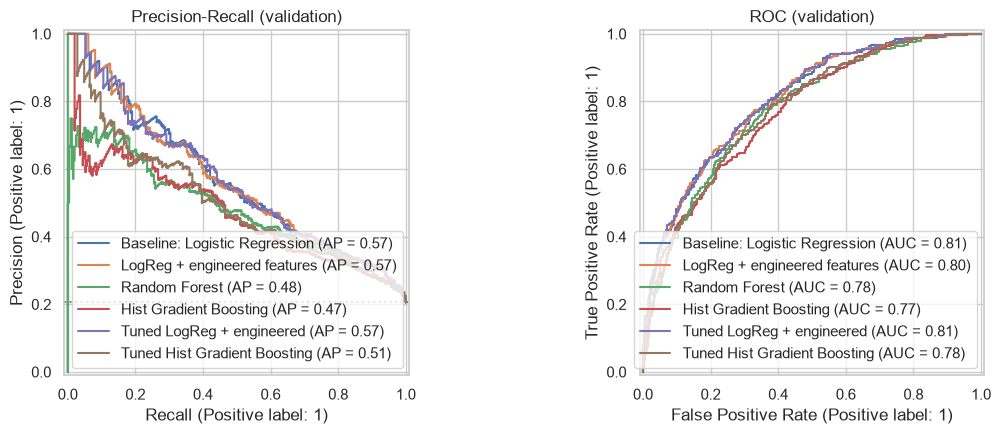

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
for n, p in val_proba.items():
    if "Dummy" in n: continue
    PrecisionRecallDisplay.from_predictions(y_val, p, name=n, ax=axes[0])
    RocCurveDisplay.from_predictions(y_val, p, name=n, ax=axes[1])
axes[0].axhline(y_val.mean(), color="grey", ls=":"); axes[0].set_title("Precision-Recall (validation)"); axes[1].set_title("ROC (validation)")
plt.tight_layout(); plt.show()

**Findings (validation set).**
- At the default 0.5 cut-off, the Random Forest has the best accuracy (0.81) but only **36% recall** — it looks good because it says "on time" a lot. Accuracy is the wrong yardstick here.
- Logistic regression variants have the best PR-AUC (~0.567) and ROC-AUC (~0.805) with ~68% recall; tuned HGB is 0.503 / 0.774.
- The tuned logistic regression (C = 0.03, more regularisation) is selected as the final model by CV PR-AUC. It is only marginally ahead of the baseline, but it is simple, fast, stable and directly explainable — a good fit for a dispatch tool. I report both honestly instead of claiming the extra features were a breakthrough.

### 9.1 Choosing the alert threshold

A threshold of 0.5 is not a business decision. Choose it from the cost of the two error types:

| Error | What happens | Assumed cost (CAD) |
|---|---|---|
| **False negative** (late shipment not flagged) | service credit + expedited re-delivery + account-manager time | **150** |
| **False positive** (on-time shipment flagged) | dispatcher spends a few minutes checking / pre-warning the customer | **40** |

*These costs are my assumptions (MapleFreight has not provided them); the sensitivity table below shows how the choice moves if they are wrong.* The threshold is picked on the **validation** set and then applied once to the untouched test set.

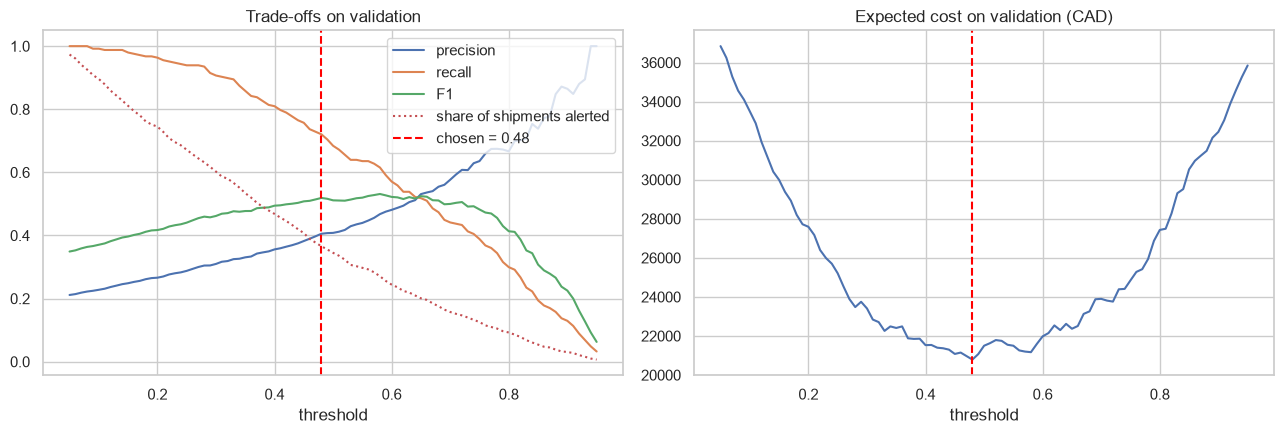

Chosen threshold = 0.48


,threshold,precision,recall,f1,alert_rate,cost
43,0.48,0.405,0.721,0.519,0.366,20790


In [77]:
FN_COST, FP_COST = 150, 40
p_val = val_proba[best_name]

grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
def cost_at(y_true, p, thr, fn=FN_COST, fp=FP_COST):
    pred = p >= thr
    return ((~pred & (y_true == 1)).sum() * fn + (pred & (y_true == 0)).sum() * fp)
costs = np.array([cost_at(y_val.values, p_val, t) for t in grid])
THRESHOLD = float(grid[costs.argmin()])

sweep = pd.DataFrame({"threshold": grid,
    "precision": [precision_score(y_val, p_val >= t, zero_division=0) for t in grid],
    "recall": [recall_score(y_val, p_val >= t) for t in grid],
    "f1": [f1_score(y_val, p_val >= t) for t in grid],
    "alert_rate": [(p_val >= t).mean() for t in grid], "cost": costs})
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(sweep.threshold, sweep.precision, label="precision"); ax[0].plot(sweep.threshold, sweep.recall, label="recall")
ax[0].plot(sweep.threshold, sweep.f1, label="F1"); ax[0].plot(sweep.threshold, sweep.alert_rate, label="share of shipments alerted", ls=":")
ax[0].axvline(THRESHOLD, color="red", ls="--", label=f"chosen = {THRESHOLD:.2f}"); ax[0].legend(); ax[0].set_xlabel("threshold"); ax[0].set_title("Trade-offs on validation")
ax[1].plot(sweep.threshold, sweep.cost); ax[1].axvline(THRESHOLD, color="red", ls="--"); ax[1].set_title("Expected cost on validation (CAD)"); ax[1].set_xlabel("threshold")
plt.tight_layout(); plt.show()
print(f"Chosen threshold = {THRESHOLD:.2f}")
sweep[sweep.threshold == THRESHOLD].round(3)

In [78]:
# Sensitivity: how does the optimal threshold move if the cost assumptions are wrong?
rows = []
for fn, fp in [(100, 40), (150, 40), (250, 40), (150, 80), (400, 40)]:
    c = np.array([cost_at(y_val.values, p_val, t, fn, fp) for t in grid]); t = grid[c.argmin()]
    rows.append({"FN cost": fn, "FP cost": fp, "best threshold": t, "recall": recall_score(y_val, p_val >= t),
                 "precision": precision_score(y_val, p_val >= t), "alert share": (p_val >= t).mean()})
pd.DataFrame(rows).round(3)

,FN cost,FP cost,best threshold,recall,precision,alert share
0,100,40,0.58,0.615,0.468,0.271
1,150,40,0.48,0.721,0.405,0.366
2,250,40,0.33,0.895,0.325,0.567
3,150,80,0.72,0.433,0.608,0.147
4,400,40,0.28,0.935,0.305,0.632


**Chosen threshold = 0.48.** Under my assumed costs (FN CAD 150, FP CAD 40) the expected-cost minimum on validation is 0.48, giving ~72% recall and ~41% precision while alerting on ~37% of shipments.

**Why not 0.5 or a higher-precision cut-off?** Missing a late shipment costs several times more than a false alarm, so favouring recall is right. **The sensitivity table shows the choice depends on the cost ratio**: if a miss is cheaper (100) or a false alarm is dearer (80), the best threshold rises to ~0.6–0.7 (alerting on only 15–27%); if a miss is much more expensive (250–400), it falls to 0.28–0.33 and dispatch gets flooded (57–63% of shipments flagged). MapleFreight should replace my assumptions with real service-credit and handling costs, and the threshold can be re-set without retraining.

**Practical caveat:** ~37% alert volume (~2,900 of 8,000 weekly shipments) is more than a human can review one by one, so alerts should be tiered by risk score (see recommendations). Note that class weighting inflates the scores, so they are *rankings*, not calibrated probabilities; the Slack message therefore shows a "risk score", not a "% chance".

### 9.2 Final test-set evaluation (baseline vs. final model)

In [79]:
test_proba = {n: fitted[n].predict_proba(X_test)[:, 1] for n in ["Dummy (always on time)", "Baseline: Logistic Regression", best_name]}
# Baseline is judged at 0.5 (its natural operating point); the final model at the cost-based threshold chosen on validation.
test_pred = {"Dummy (always on time)": (test_proba["Dummy (always on time)"] >= .5).astype(int),
             "Baseline: Logistic Regression": (test_proba["Baseline: Logistic Regression"] >= .5).astype(int),
             f"Final: {best_name} @ {THRESHOLD:.2f}": (test_proba[best_name] >= THRESHOLD).astype(int)}
final_tbl = pd.DataFrame({n: dict(accuracy=accuracy_score(y_test, p), precision=precision_score(y_test, p, zero_division=0),
                                  recall=recall_score(y_test, p), f1=f1_score(y_test, p)) for n, p in test_pred.items()}).T
final_tbl["roc_auc"] = [roc_auc_score(y_test, test_proba[k]) for k in test_proba]
final_tbl["pr_auc"] = [average_precision_score(y_test, test_proba[k]) for k in test_proba]
print("TEST SET")
final_tbl.round(3)

TEST SET


,accuracy,precision,recall,f1,roc_auc,pr_auc
Dummy (always on time),0.794,0.000,0.000,0.000,0.500,0.206
Baseline: Logistic Regression,0.754,0.442,0.745,0.555,0.829,0.601
Final: Tuned LogReg + engineered @ 0.48,0.748,0.437,0.781,0.560,0.831,0.599


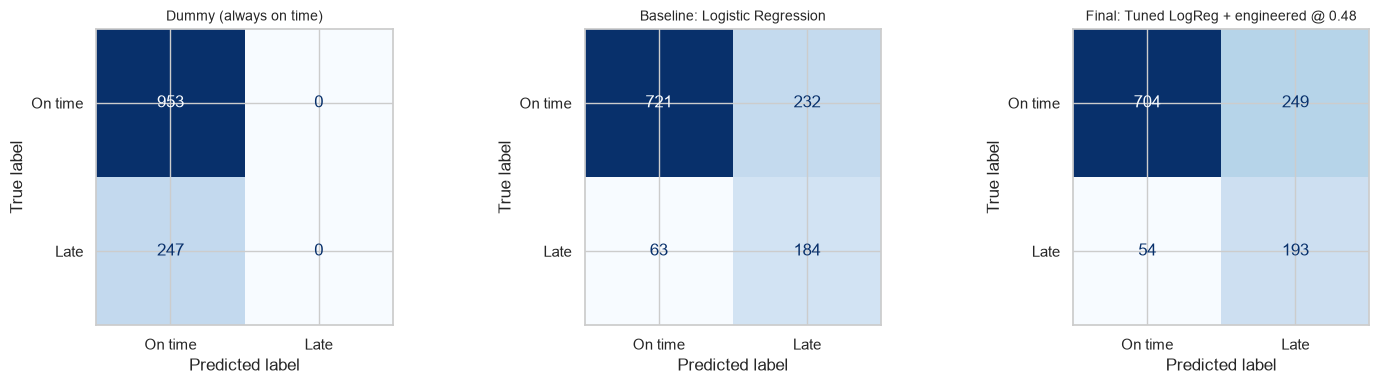

              precision    recall  f1-score   support

     On time       0.93      0.74      0.82       953
        Late       0.44      0.78      0.56       247

    accuracy                           0.75      1200
   macro avg       0.68      0.76      0.69      1200
weighted avg       0.83      0.75      0.77      1200

Caught 193 of 247 late shipments; 249 false alarms; expected cost = CAD 18,060 vs CAD 37,050 with no model.


In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (n, p) in zip(axes, test_pred.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p), display_labels=["On time", "Late"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(n, fontsize=10)
plt.tight_layout(); plt.show()
final_key = f"Final: {best_name} @ {THRESHOLD:.2f}"
print(classification_report(y_test, test_pred[final_key], target_names=["On time", "Late"]))
tn, fp, fn, tp = confusion_matrix(y_test, test_pred[final_key]).ravel()
print(f"Caught {tp} of {tp+fn} late shipments; {fp} false alarms; expected cost = CAD {fn*FN_COST + fp*FP_COST:,} "
      f"vs CAD {y_test.sum()*FN_COST:,} with no model.")

**Findings (test set, 1,200 shipments never used for fitting, tuning or threshold choice).**
- The **dummy** has 79% accuracy and 0% recall — it catches no late shipments.
- The **baseline** (logistic regression, raw features, 0.5): precision 0.44, recall 0.75, F1 0.555, PR-AUC 0.60.
- The **final model** at 0.48: precision 0.44, recall **0.78**, F1 0.56, PR-AUC 0.60. The improvement over the baseline is small (about 3 points of recall at the same precision) and well within the noise of a 247-late-shipment test set. The honest conclusion is that **tuning and feature engineering added little; most of the value is in the data and in choosing a sensible threshold.**
- In operational terms: the model catches **193 of 247** late shipments (78%) at the cost of 249 false alarms. Under the assumed costs that is ~CAD 18,060 vs ~CAD 37,050 if nothing is flagged (about 51% lower).
- Accuracy falls from 79% (dummy) to 75% — that is expected and fine: we deliberately trade accuracy for the ability to see late shipments.

## 10. Model explainability

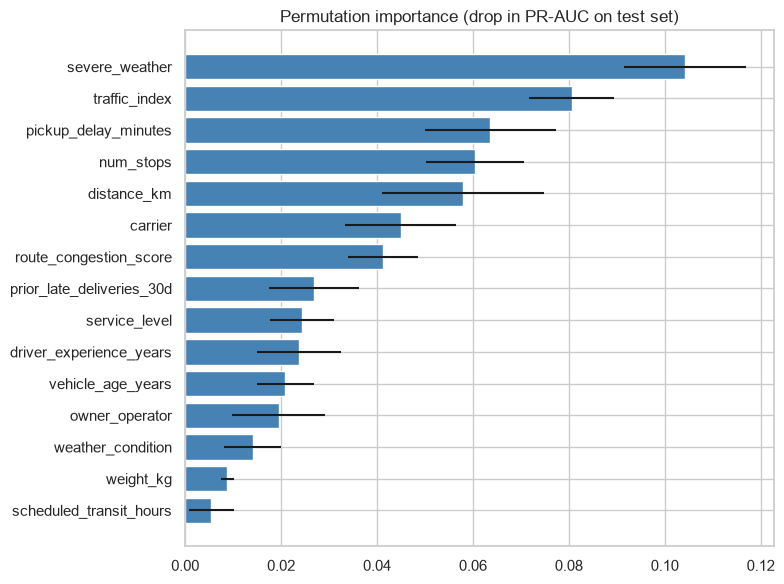

,feature,importance,std
24,severe_weather,0.1042,0.0127
17,traffic_index,0.0806,0.0089
13,pickup_delay_minutes,0.0636,0.0136
10,num_stops,0.0605,0.0102
8,distance_km,0.0579,0.0169
3,carrier,0.0449,0.0116
18,route_congestion_score,0.0413,0.0072
19,prior_late_deliveries_30d,0.0269,0.0094
4,service_level,0.0244,0.0067
14,driver_experience_years,0.0237,0.0087


In [81]:
final_model = fitted[best_name]
imp = permutation_importance(final_model, X_test, y_test, scoring="average_precision", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp_df = pd.DataFrame({"feature": X_test.columns, "importance": imp.importances_mean, "std": imp.importances_std}).sort_values("importance", ascending=False)
top = imp_df.head(15).iloc[::-1]
plt.figure(figsize=(8, 6)); plt.barh(top.feature, top.importance, xerr=top["std"], color="steelblue")
plt.title("Permutation importance (drop in PR-AUC on test set)"); plt.tight_layout(); plt.show()
imp_df.head(10).round(4)

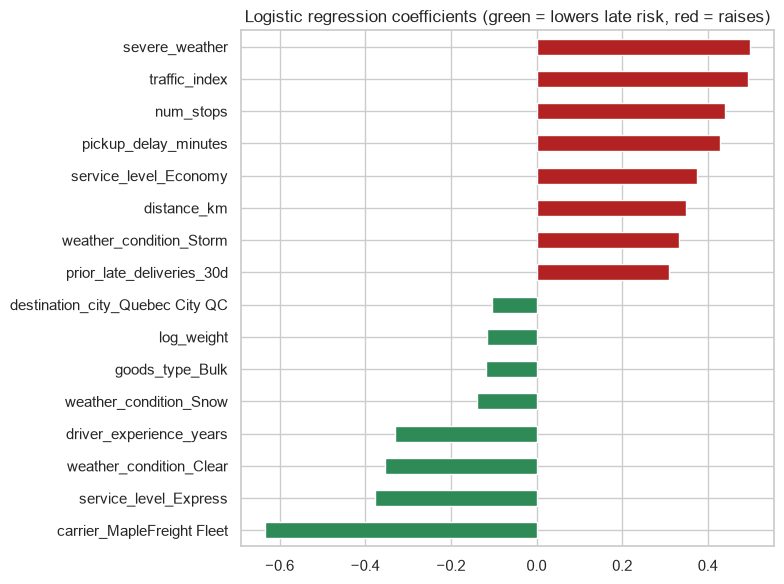

In [82]:
# Direction of effect: the tuned logistic model's coefficients (standardised numerics -> comparable magnitudes)
lr = fitted["Tuned LogReg + engineered"]
names = lr.named_steps["pre"].get_feature_names_out()
coef = pd.Series(lr.named_steps["m"].coef_[0], index=[n.split("__", 1)[1] for n in names]).sort_values()
pd.concat([coef.head(8), coef.tail(8)]).plot.barh(figsize=(8, 6), color=["seagreen"]*8 + ["firebrick"]*8)
plt.title("Logistic regression coefficients (green = lowers late risk, red = raises)"); plt.tight_layout(); plt.show()

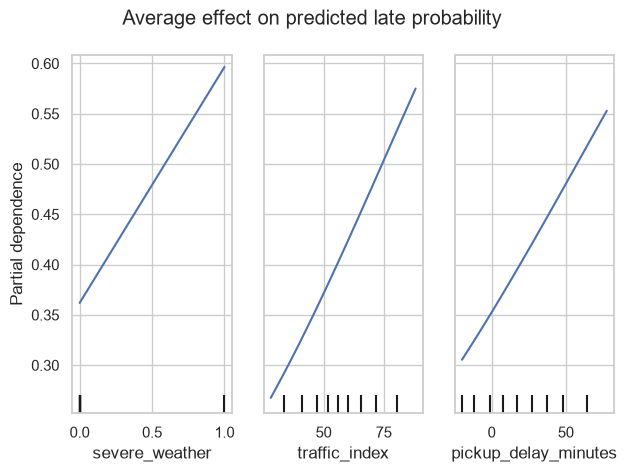

In [83]:
   # Partial dependence of the top numeric drivers
   from sklearn.inspection import PartialDependenceDisplay

   X_pdp = X_test.copy()
   X_pdp[num_cols_m] = X_pdp[num_cols_m].astype(float)   # newer scikit-learn rejects integer columns

   top_num = [f for f in imp_df.feature if f in num_cols_m][:3]
   PartialDependenceDisplay.from_estimator(final_model, X_pdp, top_num, kind="average", grid_resolution=25)
   plt.suptitle("Average effect on predicted late probability"); plt.tight_layout(); plt.show()

**Findings.** Permutation importance (drop in PR-AUC on the test set) ranks **severe weather (snow/storm)** first, then **traffic index, pickup delay, number of stops, distance and carrier**, followed by route congestion and prior late deliveries. This matches the EDA, so the model is using sensible, operationally meaningful drivers rather than artefacts. The logistic-regression coefficients show direction: severe weather, high traffic, long pickup delay, many stops, long distance, more recent carrier lates and Economy service raise risk; being on the MapleFreight own fleet, Express service and more driver experience lower it. Customer tier and city pairs contribute essentially nothing.

*Caveat: these are associations in historical data, not proven causes.*

## 11. Slack alert integration

**Setup (done outside the notebook):** created a Slack workspace + `#dispatch-alerts` channel, a Slack app with *Incoming Webhooks* enabled, and a webhook for that channel. The URL is stored **only** in a local `.env` file (`SLACK_WEBHOOK_URL=...`), which is listed in `.gitignore`; `.env.example` is committed with a placeholder. The URL is never printed in this notebook.

**Simulation.** The test set is treated as the current batch of in-transit shipments (the model never saw it). Shipments scoring ≥ the chosen threshold are *at risk*; the top few by risk score go into the message.

In [84]:
load_dotenv()
WEBHOOK_URL = os.environ.get("SLACK_WEBHOOK_URL")      # never print this value
print("Webhook configured:", bool(WEBHOOK_URL))

in_transit = X_test.copy()
in_transit["risk_score"] = test_proba[best_name]
at_risk = in_transit[in_transit.risk_score >= THRESHOLD].sort_values("risk_score", ascending=False)
print(f"{len(at_risk)} of {len(in_transit)} in-transit shipments flagged (threshold {THRESHOLD:.2f})")
at_risk[["shipment_id", "destination_city", "carrier", "weather_condition", "risk_score"]].head(8).round(2)

Webhook configured: True
442 of 1200 in-transit shipments flagged (threshold 0.48)


,shipment_id,destination_city,carrier,weather_condition,risk_score
554,SHP-103300,Winnipeg MB,NorthStar Carriers,Snow,0.97
5268,SHP-100936,Calgary AB,PrairieLine,Storm,0.97
1555,SHP-103230,Regina SK,Contract Owner-Op,Snow,0.97
3041,SHP-105511,Ottawa ON,NorthStar Carriers,Snow,0.97
2110,SHP-102910,Edmonton AB,QuebecExpress,Storm,0.96
3632,SHP-100273,Hamilton ON,NorthStar Carriers,Snow,0.96
939,SHP-101673,Sudbury ON,Contract Owner-Op,Snow,0.95
1481,SHP-104995,Winnipeg MB,NorthStar Carriers,Storm,0.95


In [85]:
def build_alert(at_risk, total, threshold, top_n=5):
    lines = [f":rotating_light: *{len(at_risk)} of {total} in-transit shipments at risk of late delivery* (risk score ≥ {threshold:.2f})", ""]
    for i, (_, r) in enumerate(at_risk.head(top_n).iterrows(), 1):
        lines.append(f"{i}. `{r.shipment_id}` → {r.destination_city} | {r.carrier} | risk score *{r.risk_score:.2f}*")
    if len(at_risk) > top_n:
        lines.append(f"…and {len(at_risk) - top_n} more. Review, re-route or warn the customer.")
    return "\n".join(lines)

def send_slack(message, webhook_url):
    if not webhook_url:
        print("No SLACK_WEBHOOK_URL set -> message NOT sent. Preview:\n"); print(message); return None
    resp = requests.post(webhook_url, json={"text": message}, timeout=10)
    print("Slack response:", resp.status_code, resp.text)     # 200 / 'ok' means delivered
    return resp.status_code

message = build_alert(at_risk, len(in_transit), THRESHOLD)
print(message, "\n" + "-" * 60)
status = send_slack(message, WEBHOOK_URL)

:rotating_light: *442 of 1200 in-transit shipments at risk of late delivery* (risk score ≥ 0.48)

1. `SHP-103300` → Winnipeg MB | NorthStar Carriers | risk score *0.97*
2. `SHP-100936` → Calgary AB | PrairieLine | risk score *0.97*
3. `SHP-103230` → Regina SK | Contract Owner-Op | risk score *0.97*
4. `SHP-105511` → Ottawa ON | NorthStar Carriers | risk score *0.97*
5. `SHP-102910` → Edmonton AB | QuebecExpress | risk score *0.96*
…and 437 more. Review, re-route or warn the customer. 
------------------------------------------------------------
Slack response: 200 ok


**Findings.** The alert is built from the highest-risk in-transit shipments and posts a short mobile-friendly message: the count at risk, then ID, destination, carrier and risk score for the top five. The webhook URL is read from `.env` and never printed. If it is missing the function prints a preview rather than failing, so the notebook still runs from a clean kernel. When the webhook is configured, `Slack response: 200 ok` confirms delivery, and the screenshot of the real message is saved at `screenshots/slack_alert.png`.

## 12. Recommendations

Each recommendation is tied to evidence in this notebook (associations, not proven causes).

1. **Treat snow/storm at dispatch as a trigger.** Late rates are 33.6% (snow) and 46.5% (storm) vs 14.1% in clear weather, and the forecast is known at dispatch. Pre-warn customers and add buffer to promised windows on these loads.
2. **Keep weather-exposed freight off the weakest carrier/weather combinations.** Contract owner-operators are late 36% overall and 55%+ in snow/storm, versus 12.8% for the own fleet (7% in clear weather). Prefer the own fleet in severe weather and add on-time clauses and carrier scorecards for owner-operators.
3. **Cap intermediate stops on tight windows.** Lateness climbs from 12% (no stops) to 29% (5 stops). Consolidate stops or lengthen the promise on multi-stop routes.
4. **Escalate at pickup.** Pickups more than 30 minutes late are late ~26% of the time vs ~15% for on-time/early pickups. Re-score the shipment when pickup is recorded and alert if risk crosses the threshold.
5. **Re-set Economy promise windows.** Economy runs 26.6% late vs 15.1% for Express; promises appear too tight for the service level.
6. **Use traffic and carrier history for routing.** The highest-traffic quartile is late 29.8% vs 13.1%, and carriers with 4+ late deliveries in the past 30 days are at 30%+. Re-route or re-assign when both are high.
7. **Pair inexperienced drivers (<3 years: 24.6% late) with lower-risk lanes** rather than storm or multi-stop runs.
8. **Run the alerting in tiers.** Page dispatch only for the top few percent (very high scores), put the rest into a daily digest. Priority tier does not predict lateness, so don't rank alerts by it.
9. **Make it a process.** Replace my assumed costs (FN 150 / FP 40) with real ones and re-set the threshold; measure alert-to-action rates in Slack; retrain monthly; and fix the data issues at the source (gram-unit weights, case-inconsistent service levels, duplicate/conflicting shipment IDs).

**Limitations.** One year of data, ~21% late, a test set with 247 late shipments, and a threshold that depends on assumed costs. The Slack run is a simulation on historical data; a real deployment needs a feed of live in-transit shipments.